<a href="https://colab.research.google.com/github/shubh21295-rgb/house_price/blob/main/fake_news_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. ⚙️ Environment Setup

In [7]:
pip install nltk scikit-learn pandas numpy

In [8]:
# Install any missing packages (quietly)
!pip install -q wordcloud kagglehub

import os
import re
import string
import pickle
import shutil
import warnings
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

# Download NLTK resources quietly
for resource in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress warnings and set plot style
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("✅ Environment ready.")

✅ Environment ready.


In [9]:
def find_file(root_dir, filename):
    """Search a directory tree for a file and return its full path."""
    for dirpath, _, filenames in os.walk(root_dir):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    raise FileNotFoundError(f"{filename} not found under {root_dir}")


fake_path, true_path = None, None

# ---------- Option A: kagglehub (recommended) ----------
try:
    import kagglehub
    dataset_dir = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
    print("✅ Option A: dataset downloaded to:", dataset_dir)
    fake_path = find_file(dataset_dir, "Fake.csv")
    true_path = find_file(dataset_dir, "True.csv")

# ---------- Option B: Google Drive (fallback) ----------
except Exception as e:
    print("⚠️ Option A (kagglehub) failed:", repr(e))
    print("➡️ Switching to Option B: Google Drive.")
    print("   Make sure Fake.csv and True.csv are in the root of 'My Drive'.")
    from google.colab import drive
    drive.mount("/content/drive")
    fake_path = "/content/drive/MyDrive/Fake.csv"
    true_path = "/content/drive/MyDrive/True.csv"
    if not (os.path.exists(fake_path) and os.path.exists(true_path)):
        raise FileNotFoundError(
            "Could not find Fake.csv and True.csv in /content/drive/MyDrive/. "
            "Download them from Kaggle "
            "(https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset), "
            "upload them to your Drive root, and re-run this cell."
        )

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("\nFake.csv shape:", fake_df.shape)
print("True.csv shape:", true_df.shape)

print("\n--- Fake.csv (head) ---")
display(fake_df.head())
print("\n--- True.csv (head) ---")
display(true_df.head())

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
✅ Option A: dataset downloaded to: /kaggle/input/fake-and-real-news-dataset

Fake.csv shape: (23481, 4)
True.csv shape: (21417, 4)

--- Fake.csv (head) ---


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



--- True.csv (head) ---


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


Null values in Fake.csv:
 title      0
text       0
subject    0
date       0
dtype: int64 

Null values in True.csv:
 title      0
text       0
subject    0
date       0
dtype: int64 

Duplicate rows in Fake.csv: 3
Duplicate rows in True.csv: 206

Combined shape (before de-duplication): (44898, 5)
Removed 5793 duplicate articles. New shape: (39105, 5)


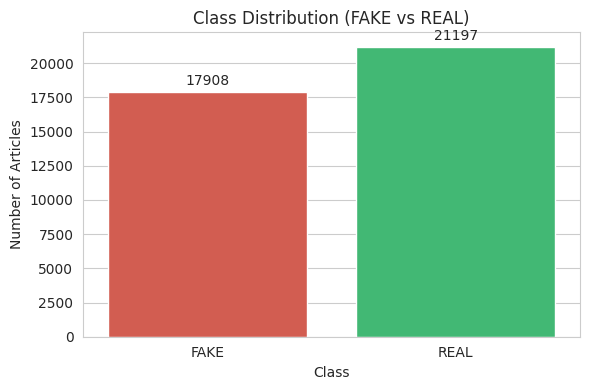

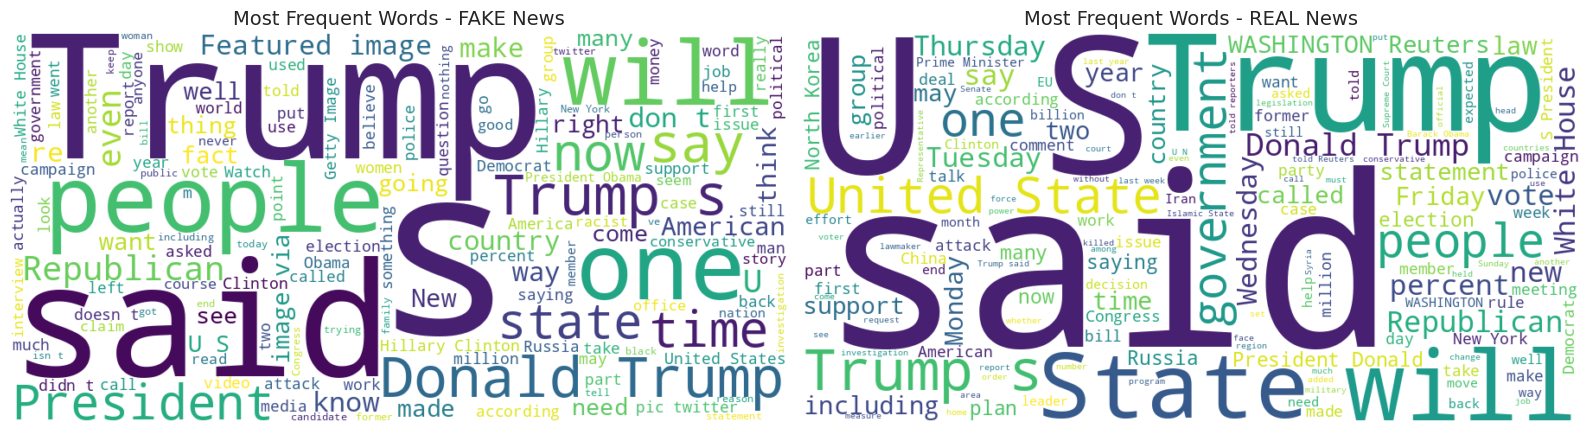

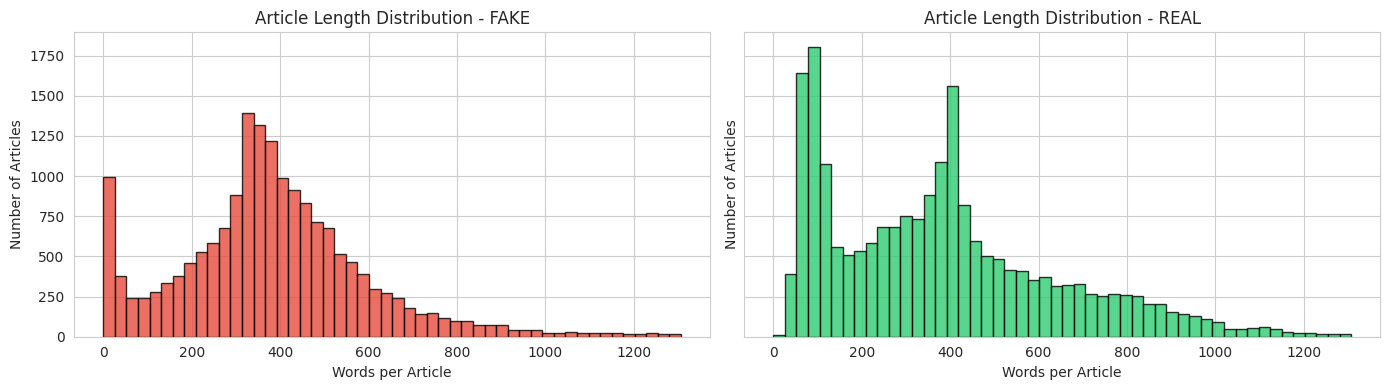


Average words per article:
class
FAKE    414.7
REAL    384.9
Name: word_count, dtype: float64


In [10]:
# ---- Nulls & duplicates (before merging) ----
print("Null values in Fake.csv:\n", fake_df.isnull().sum(), "\n")
print("Null values in True.csv:\n", true_df.isnull().sum(), "\n")
print("Duplicate rows in Fake.csv:", fake_df.duplicated().sum())
print("Duplicate rows in True.csv:", true_df.duplicated().sum())

# ---- Labels & combine (FAKE = 0, REAL = 1) ----
fake_df["label"] = 0
true_df["label"] = 1
df = pd.concat([fake_df, true_df], ignore_index=True)
print("\nCombined shape (before de-duplication):", df.shape)

# Handle missing text, drop duplicate articles, shuffle
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")
n_dupes = df.duplicated(subset=["title", "text"]).sum()
df = df.drop_duplicates(subset=["title", "text"]).reset_index(drop=True)
print(f"Removed {n_dupes} duplicate articles. New shape: {df.shape}")

df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df["class"] = df["label"].map({0: "FAKE", 1: "REAL"})

# ---- 1) Class distribution ----
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="class", hue="class", order=["FAKE", "REAL"],
                   palette={"FAKE": "#e74c3c", "REAL": "#2ecc71"}, legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title("Class Distribution (FAKE vs REAL)")
plt.xlabel("Class")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

# ---- 2) Word clouds (sample for speed) ----
def build_wordcloud(texts):
    return WordCloud(width=900, height=450, background_color="white",
                     stopwords=STOPWORDS, max_words=150,
                     random_state=RANDOM_STATE).generate(" ".join(texts))

fake_texts = df.loc[df["label"] == 0, "text"]
real_texts = df.loc[df["label"] == 1, "text"]
fake_sample = fake_texts.sample(min(3000, len(fake_texts)), random_state=RANDOM_STATE)
real_sample = real_texts.sample(min(3000, len(real_texts)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(build_wordcloud(fake_sample), interpolation="bilinear")
axes[0].set_title("Most Frequent Words - FAKE News", fontsize=14)
axes[0].axis("off")
axes[1].imshow(build_wordcloud(real_sample), interpolation="bilinear")
axes[1].set_title("Most Frequent Words - REAL News", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()

# ---- 3) Article length distributions (in words) ----
df["word_count"] = df["text"].str.split().str.len()
cap = df["word_count"].quantile(0.99)  # clip extreme outliers for readability

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, cls, color in zip(axes, ["FAKE", "REAL"], ["#e74c3c", "#2ecc71"]):
    subset = df[(df["class"] == cls) & (df["word_count"] <= cap)]
    ax.hist(subset["word_count"], bins=50, color=color, edgecolor="black", alpha=0.8)
    ax.set_title(f"Article Length Distribution - {cls}")
    ax.set_xlabel("Words per Article")
    ax.set_ylabel("Number of Articles")
plt.tight_layout()
plt.show()

print("\nAverage words per article:")
print(df.groupby("class")["word_count"].mean().round(1))

In [11]:
from tqdm.auto import tqdm
tqdm.pandas()

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")
PUNCT_TABLE = str.maketrans({ch: " " for ch in string.punctuation})


@lru_cache(maxsize=None)
def lemmatize_word(word):
    """Cached WordNet lemmatization (huge speed-up on repeated words)."""
    return lemmatizer.lemmatize(word)


def clean_text(text):
    """Lowercase, strip noise, remove stopwords, and lemmatize."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = URL_RE.sub(" ", text)          # URLs
    text = HTML_RE.sub(" ", text)         # HTML tags
    text = MENTION_RE.sub(" ", text)      # @mentions
    text = HASHTAG_RE.sub(" ", text)      # #hashtags
    text = text.translate(PUNCT_TABLE)    # punctuation
    text = re.sub(r"\d+", " ", text)      # digits
    text = re.sub(r"[^a-z\s]", " ", text) # any leftover non-letters
    text = re.sub(r"\s+", " ", text).strip()  # extra whitespace
    tokens = [lemmatize_word(tok) for tok in text.split()
              if tok not in STOP_WORDS and len(tok) > 1]
    return " ".join(tokens)


# Combine title + text and clean
df["content"] = df["title"] + " " + df["text"]
df["clean_content"] = df["content"].progress_apply(clean_text)

# Drop articles that became empty after cleaning
before = len(df)
df = df[df["clean_content"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"\nDropped {before - len(df)} empty articles. Final dataset shape: {df.shape}")

# Before / after example
example = df.loc[0, "content"]
print("\n--- BEFORE (first 400 chars) ---")
print(example[:400])
print("\n--- AFTER (first 400 chars) ---")
print(df.loc[0, "clean_content"][:400])

  0%|          | 0/39105 [00:00<?, ?it/s]


Dropped 5 empty articles. Final dataset shape: (39100, 9)

--- BEFORE (first 400 chars) ---
Many 'lost' voters say they have found their candidate in Trump WASHINGTON/NEW YORK (Reuters) - Ted Wade hasn’t cared about politics enough to cast a vote in a U.S. presidential election for almost a quarter of a century, back when he supported Ross Perot’s independent candidacy in 1992. But Republican Donald Trump’s 2016 White House bid has motivated Wade to get involved and he plans to support t

--- AFTER (first 400 chars) ---
many lost voter say found candidate trump washington new york reuters ted wade cared politics enough cast vote presidential election almost quarter century back supported ross perot independent candidacy republican donald trump white house bid motivated wade get involved plan support real estate mogul nevada nominating caucus next month trump non politician fix chaos washington say one american pl


In [12]:
from tqdm.auto import tqdm
tqdm.pandas()

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")
PUNCT_TABLE = str.maketrans({ch: " " for ch in string.punctuation})


@lru_cache(maxsize=None)
def lemmatize_word(word):
    """Cached WordNet lemmatization (huge speed-up on repeated words)."""
    return lemmatizer.lemmatize(word)


def clean_text(text):
    """Lowercase, strip noise, remove stopwords, and lemmatize."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = URL_RE.sub(" ", text)          # URLs
    text = HTML_RE.sub(" ", text)         # HTML tags
    text = MENTION_RE.sub(" ", text)      # @mentions
    text = HASHTAG_RE.sub(" ", text)      # #hashtags
    text = text.translate(PUNCT_TABLE)    # punctuation
    text = re.sub(r"\d+", " ", text)      # digits
    text = re.sub(r"[^a-z\s]", " ", text) # any leftover non-letters
    text = re.sub(r"\s+", " ", text).strip()  # extra whitespace
    tokens = [lemmatize_word(tok) for tok in text.split()
              if tok not in STOP_WORDS and len(tok) > 1]
    return " ".join(tokens)


# Combine title + text and clean
df["content"] = df["title"] + " " + df["text"]
df["clean_content"] = df["content"].progress_apply(clean_text)

# Drop articles that became empty after cleaning
before = len(df)
df = df[df["clean_content"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"\nDropped {before - len(df)} empty articles. Final dataset shape: {df.shape}")

# Before / after example
example = df.loc[0, "content"]
print("\n--- BEFORE (first 400 chars) ---")
print(example[:400])
print("\n--- AFTER (first 400 chars) ---")
print(df.loc[0, "clean_content"][:400])

  0%|          | 0/39100 [00:00<?, ?it/s]


Dropped 0 empty articles. Final dataset shape: (39100, 9)

--- BEFORE (first 400 chars) ---
Many 'lost' voters say they have found their candidate in Trump WASHINGTON/NEW YORK (Reuters) - Ted Wade hasn’t cared about politics enough to cast a vote in a U.S. presidential election for almost a quarter of a century, back when he supported Ross Perot’s independent candidacy in 1992. But Republican Donald Trump’s 2016 White House bid has motivated Wade to get involved and he plans to support t

--- AFTER (first 400 chars) ---
many lost voter say found candidate trump washington new york reuters ted wade cared politics enough cast vote presidential election almost quarter century back supported ross perot independent candidacy republican donald trump white house bid motivated wade get involved plan support real estate mogul nevada nominating caucus next month trump non politician fix chaos washington say one american pl


In [13]:
X = df["clean_content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.7)
X_train_tfidf = tfidf.fit_transform(X_train)   # fit on train only
X_test_tfidf = tfidf.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])
print("TF-IDF train matrix shape:", X_train_tfidf.shape)
print("TF-IDF test matrix shape: ", X_test_tfidf.shape)
print("\nClass balance in train:\n", y_train.value_counts(normalize=True).round(3))
print("\nClass balance in test:\n", y_test.value_counts(normalize=True).round(3))

Training samples: 31280
Testing samples:  7820
TF-IDF train matrix shape: (31280, 5000)
TF-IDF test matrix shape:  (7820, 5000)

Class balance in train:
 label
1    0.542
0    0.458
Name: proportion, dtype: float64

Class balance in test:
 label
1    0.542
0    0.458
Name: proportion, dtype: float64


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=50, random_state=RANDOM_STATE),
    "Multinomial Naive Bayes": MultinomialNB(),
}

trained_models = {}
results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    trained_models[name] = model
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }
    print(f"✅ Trained {name}")

results_df = pd.DataFrame(results).T.sort_values("F1-Score", ascending=False).round(4)
print("\n📊 Model comparison (sorted by F1-Score):")
display(results_df)

✅ Trained Logistic Regression
✅ Trained Passive Aggressive
✅ Trained Multinomial Naive Bayes

📊 Model comparison (sorted by F1-Score):


,Accuracy,Precision,Recall,F1-Score
Passive Aggressive,0.9925,0.9913,0.9948,0.9931
Logistic Regression,0.9881,0.9834,0.9948,0.9891
Multinomial Naive Bayes,0.9463,0.9500,0.9509,0.9505


🏆 Best model by F1-Score: Passive Aggressive

Classification Report:

              precision    recall  f1-score   support

        FAKE     0.9938    0.9897    0.9917      3581
        REAL     0.9913    0.9948    0.9931      4239

    accuracy                         0.9925      7820
   macro avg     0.9926    0.9922    0.9924      7820
weighted avg     0.9925    0.9925    0.9925      7820



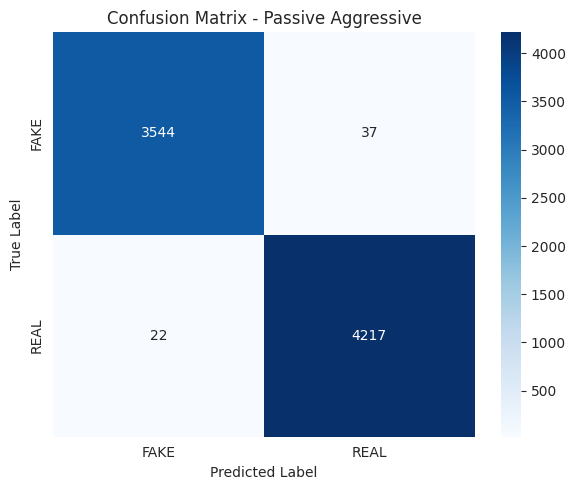

ℹ️ Skipping ROC for 'Passive Aggressive' (no predict_proba).


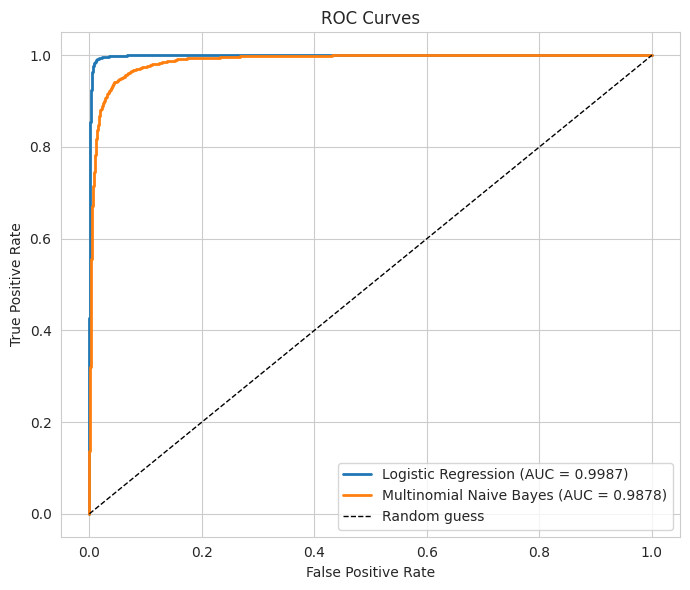

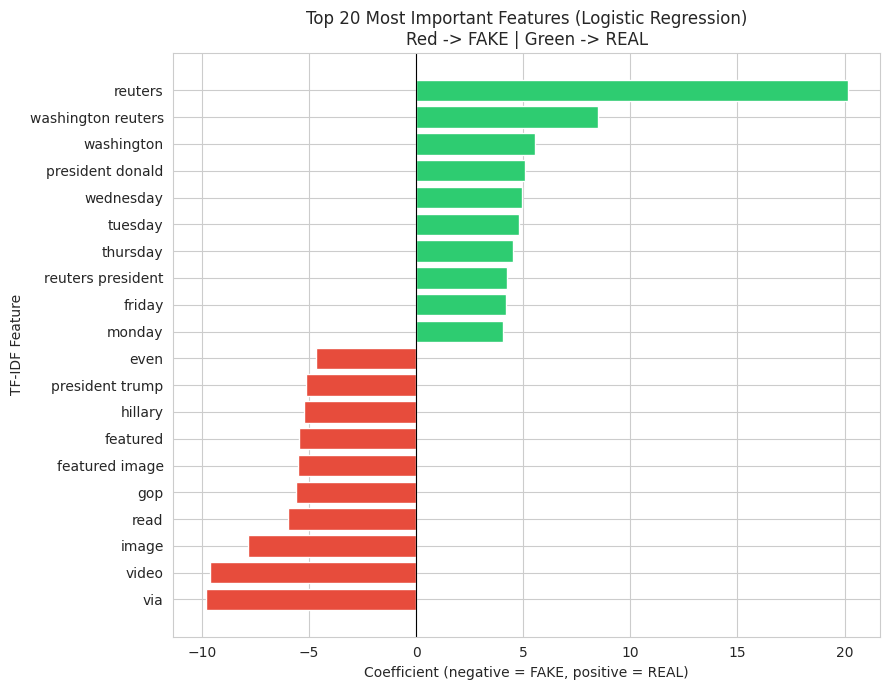

Saved: /content/confusion_matrix.png and /content/roc_curve.png


In [15]:
os.makedirs("/content", exist_ok=True)

# ---- Pick best model by F1 ----
best_name = results_df["F1-Score"].idxmax()
best_model = trained_models[best_name]
print(f"🏆 Best model by F1-Score: {best_name}\n")

y_pred_best = best_model.predict(X_test_tfidf)

# ---- Classification report ----
print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=["FAKE", "REAL"], digits=4))

# ---- Confusion matrix ----
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=["FAKE", "REAL"], yticklabels=["FAKE", "REAL"])
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- ROC curves (only models with predict_proba) ----
plt.figure(figsize=(7, 6))
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_tfidf)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")
    else:
        print(f"ℹ️ Skipping ROC for '{name}' (no predict_proba).")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random guess")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Top features from Logistic Regression ----
lr_model = trained_models["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_fake_idx = np.argsort(coefs)[:10]       # most negative -> FAKE (label 0)
top_real_idx = np.argsort(coefs)[-10:]      # most positive -> REAL (label 1)
top_idx = np.concatenate([top_fake_idx, top_real_idx])

top_df = pd.DataFrame({"feature": feature_names[top_idx], "coefficient": coefs[top_idx]})
top_df = top_df.sort_values("coefficient")
colors = ["#e74c3c" if c < 0 else "#2ecc71" for c in top_df["coefficient"]]

plt.figure(figsize=(9, 7))
plt.barh(top_df["feature"], top_df["coefficient"], color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 20 Most Important Features (Logistic Regression)\nRed -> FAKE | Green -> REAL")
plt.xlabel("Coefficient (negative = FAKE, positive = REAL)")
plt.ylabel("TF-IDF Feature")
plt.tight_layout()
plt.show()

print("Saved: /content/confusion_matrix.png and /content/roc_curve.png")

In [16]:
MODEL_PATH = "/content/fake_news_model.pkl"
VECTORIZER_PATH = "/content/tfidf_vectorizer.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_model, f)
with open(VECTORIZER_PATH, "wb") as f:
    pickle.dump(tfidf, f)

print(f"✅ Saved best model ({best_name}) -> {MODEL_PATH}")
print(f"✅ Saved TF-IDF vectorizer -> {VECTORIZER_PATH}")

# Optional: copy to Google Drive if it is already mounted
if os.path.isdir("/content/drive/MyDrive"):
    for path in (MODEL_PATH, VECTORIZER_PATH):
        shutil.copy(path, "/content/drive/MyDrive/")
    print("✅ Copies also saved to /content/drive/MyDrive/")
else:
    print("ℹ️ Google Drive not mounted - skipping Drive copy.")

# Trigger browser downloads (Colab only)
try:
    from google.colab import files
    files.download(MODEL_PATH)
    files.download(VECTORIZER_PATH)
except Exception as e:
    print("ℹ️ Automatic download skipped:", repr(e))

✅ Saved best model (Passive Aggressive) -> /content/fake_news_model.pkl
✅ Saved TF-IDF vectorizer -> /content/tfidf_vectorizer.pkl
ℹ️ Google Drive not mounted - skipping Drive copy.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Load saved artifacts
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)
with open(VECTORIZER_PATH, "rb") as f:
    loaded_vectorizer = pickle.load(f)


def predict_news(text):
    """Return (label, confidence) for a news headline or article."""
    cleaned = clean_text(text)
    if not cleaned:
        return "UNKNOWN", 0.0

    vec = loaded_vectorizer.transform([cleaned])

    if hasattr(loaded_model, "predict_proba"):
        proba = loaded_model.predict_proba(vec)[0]
        pred = int(np.argmax(proba))
        confidence = float(proba[pred])
    else:
        score = float(loaded_model.decision_function(vec)[0])
        p_real = 1.0 / (1.0 + np.exp(-score))
        pred = int(score > 0)
        confidence = p_real if pred == 1 else 1.0 - p_real

    return ("REAL" if pred == 1 else "FAKE"), confidence


samples = {
    "Clearly fake-sounding": "SHOCKING: Secret elites confirm Obama is a lizard person controlling the world, "
                             "mainstream media hiding the truth from you!",
    "Clearly real-sounding": "WASHINGTON (Reuters) - The U.S. Senate on Tuesday voted to approve a bipartisan "
                             "spending bill to avert a government shutdown, officials said.",
    "Neutral": "The city council will hold a public meeting on Thursday to discuss local road maintenance.",
    "Short / ambiguous": "Breaking news today",
}

print("=" * 80)
print(f"{'Sample Type':<24}{'Prediction':<12}{'Confidence':<12}Text")
print("=" * 80)
for kind, text in samples.items():
    label, conf = predict_news(text)
    short_text = text if len(text) <= 60 else text[:57] + "..."
    print(f"{kind:<24}{label:<12}{conf * 100:>6.2f}%     {short_text}")
print("=" * 80)

Sample Type             Prediction  Confidence  Text
Clearly fake-sounding   FAKE         97.51%     SHOCKING: Secret elites confirm Obama is a lizard person ...
Clearly real-sounding   REAL         99.86%     WASHINGTON (Reuters) - The U.S. Senate on Tuesday voted t...
Neutral                 REAL         69.31%     The city council will hold a public meeting on Thursday t...
Short / ambiguous       FAKE         99.98%     Breaking news today


In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

text_input = widgets.Textarea(
    value="",
    placeholder="Paste a news headline or full article here...",
    description="News text:",
    layout=widgets.Layout(width="100%", height="160px"),
    style={"description_width": "80px"},
)
predict_button = widgets.Button(description="Predict", button_style="primary", icon="search")
clear_button = widgets.Button(description="Clear", icon="trash")
output_area = widgets.Output()


def on_predict_clicked(_):
    with output_area:
        clear_output(wait=True)
        text = text_input.value.strip()
        if not text:
            print("⚠️ Please enter some news text first.")
            return
        label, conf = predict_news(text)
        if label == "UNKNOWN":
            print("⚠️ Not enough meaningful text to classify. Try a longer input.")
            return
        color = "#2ecc71" if label == "REAL" else "#e74c3c"
        icon = "✅" if label == "REAL" else "🚨"
        display(HTML(
            f"<div style='padding:12px;border-radius:8px;border:2px solid {color};'>"
            f"<h3 style='margin:0;color:{color};'>{icon} Prediction: {label}</h3>"
            f"<p style='margin:6px 0 0 0;'>Confidence: <b>{conf * 100:.2f}%</b></p></div>"
        ))


def on_clear_clicked(_):
    text_input.value = ""
    with output_area:
        clear_output()


predict_button.on_click(on_predict_clicked)
clear_button.on_click(on_clear_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>🕵️ Fake News Detector</h3>"),
    text_input,
    widgets.HBox([predict_button, clear_button]),
    output_area,
]))